# 数据理解与探索性分析

本 Notebook 展示客户流失数据的基础探索分析（EDA），重点关注流失分布、关键类别特征流失率和数值特征关系。

## 1. 数据读取与环境准备

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams['figure.dpi'] = 120

def find_project_root():
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / 'config.yaml').exists() and (p / 'data').exists():
            return p
    return cwd

project_root = find_project_root()
raw_path = project_root / 'data' / 'raw' / 'Telco-Customer-Churn.csv'
cleaned_path = project_root / 'data' / 'processed' / 'churn_cleaned.csv'
fig_dir = project_root / 'outputs' / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

raw_df = pd.read_csv(raw_path)
cleaned_df = pd.read_csv(cleaned_path)
raw_df['TotalCharges_num'] = pd.to_numeric(raw_df['TotalCharges'], errors='coerce')
raw_df['Churn_flag'] = raw_df['Churn'].map({'Yes': 1, 'No': 0})

print('项目根目录:', project_root)
print('原始数据维度:', raw_df.shape)
print('清洗后数据维度:', cleaned_df.shape)

项目根目录: E:\TelecomCustomer_ChurnPrediction
原始数据维度: (7043, 23)
清洗后数据维度: (7043, 26)


## 2. 原始数据维度、字段类型与缺失值统计

In [2]:
dtype_df = raw_df.dtypes.reset_index()
dtype_df.columns = ['字段名', '数据类型']
missing_df = raw_df.isna().sum().reset_index()
missing_df.columns = ['字段名', '缺失数量']
missing_df['缺失占比'] = (missing_df['缺失数量'] / len(raw_df)).round(4)

display(raw_df.head())
display(dtype_df)
display(missing_df.sort_values('缺失数量', ascending=False))

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_num,Churn_flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.5,No,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,151.65,1


,字段名,数据类型
0,customerID,str
1,gender,str
2,SeniorCitizen,int64
3,Partner,str
4,Dependents,str
5,tenure,int64
6,PhoneService,str
7,MultipleLines,str
8,InternetService,str
9,OnlineSecurity,str


,字段名,缺失数量,缺失占比
21,TotalCharges_num,11,0.0016
1,gender,0,0.0000
0,customerID,0,0.0000
3,Partner,0,0.0000
4,Dependents,0,0.0000
5,tenure,0,0.0000
2,SeniorCitizen,0,0.0000
6,PhoneService,0,0.0000
7,MultipleLines,0,0.0000
9,OnlineSecurity,0,0.0000


## 3. Churn 目标变量分布

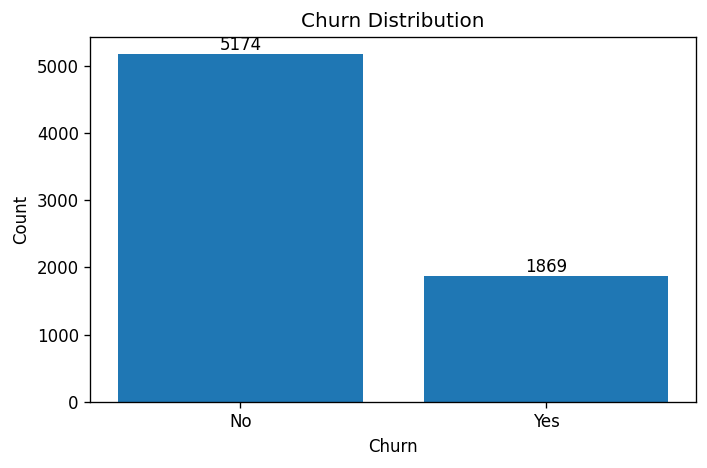

已保存图表: E:\TelecomCustomer_ChurnPrediction\outputs\figures\eda_churn_distribution.png


In [3]:
churn_counts = raw_df['Churn'].value_counts().reindex(['No', 'Yes'])
plt.figure(figsize=(6, 4))
plt.bar(churn_counts.index, churn_counts.values)
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
for i, v in enumerate(churn_counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.tight_layout()
out_path = fig_dir / 'eda_churn_distribution.png'
plt.savefig(out_path, dpi=150)
plt.show()
print('已保存图表:', out_path)

## 4. tenure、MonthlyCharges、TotalCharges 分布

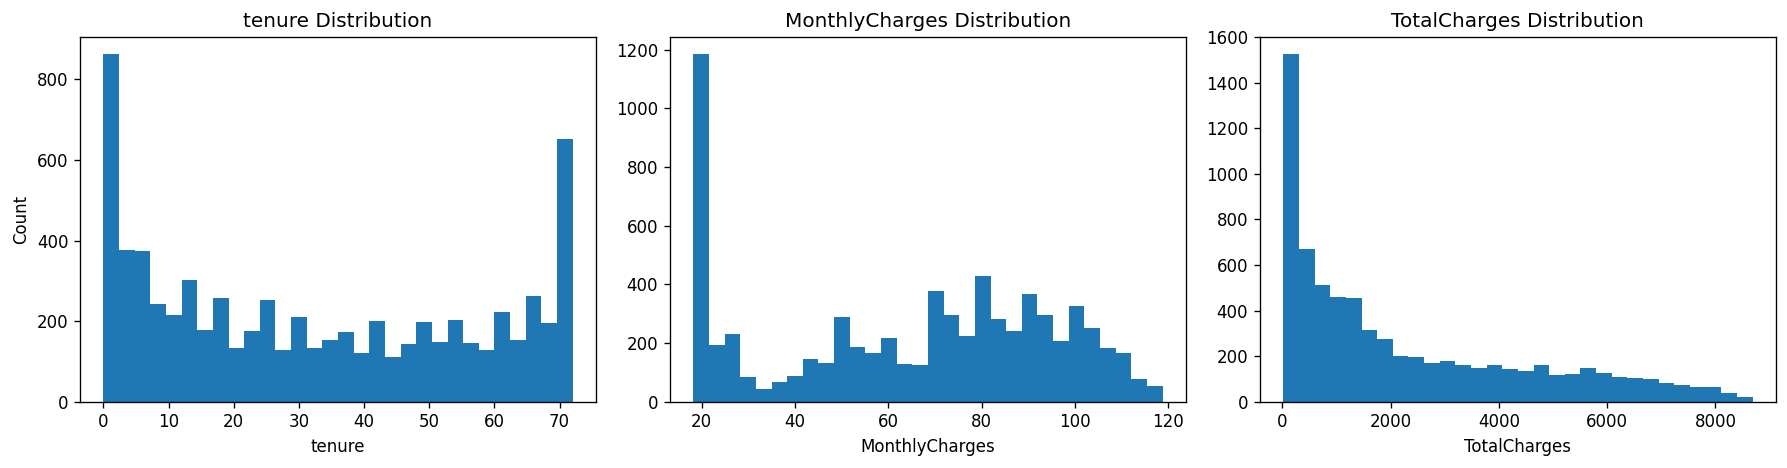

已保存图表: E:\TelecomCustomer_ChurnPrediction\outputs\figures\eda_numeric_distribution.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(raw_df['tenure'].dropna(), bins=30)
axes[0].set_title('tenure Distribution')
axes[0].set_xlabel('tenure')
axes[0].set_ylabel('Count')

axes[1].hist(raw_df['MonthlyCharges'].dropna(), bins=30)
axes[1].set_title('MonthlyCharges Distribution')
axes[1].set_xlabel('MonthlyCharges')

axes[2].hist(raw_df['TotalCharges_num'].dropna(), bins=30)
axes[2].set_title('TotalCharges Distribution')
axes[2].set_xlabel('TotalCharges')

fig.tight_layout()
out_path = fig_dir / 'eda_numeric_distribution.png'
fig.savefig(out_path, dpi=150)
plt.show()
print('已保存图表:', out_path)

## 5. Contract 与 Churn 的交叉流失率分析

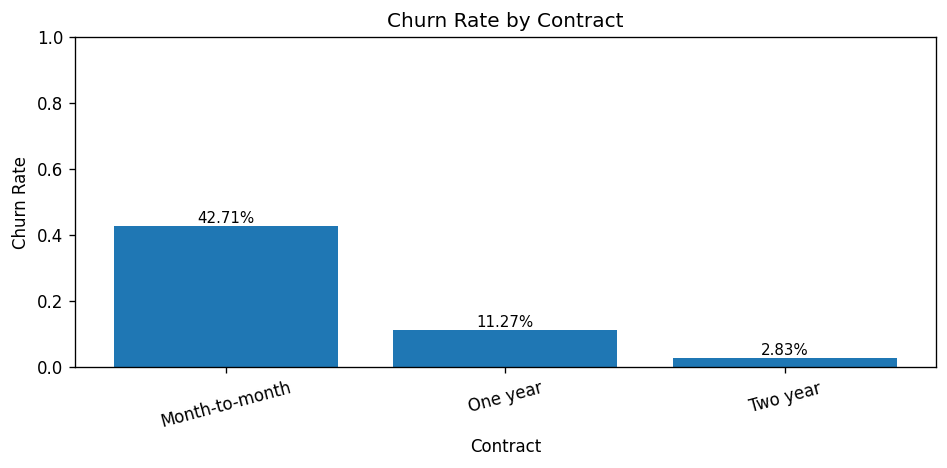

已保存图表: E:\TelecomCustomer_ChurnPrediction\outputs\figures\eda_contract_churn_rate.png


,流失率
Contract,
Month-to-month,0.427097
One year,0.112695
Two year,0.028319


In [5]:
contract_rate = raw_df.groupby('Contract', dropna=False)['Churn_flag'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
plt.bar(contract_rate.index, contract_rate.values)
plt.title('Churn Rate by Contract')
plt.xlabel('Contract')
plt.ylabel('Churn Rate')
plt.ylim(0, 1)
plt.xticks(rotation=15)
for x, y in zip(contract_rate.index, contract_rate.values):
    plt.text(x, y, f'{y:.2%}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
out_path = fig_dir / 'eda_contract_churn_rate.png'
plt.savefig(out_path, dpi=150)
plt.show()
print('已保存图表:', out_path)
display(contract_rate.rename('流失率').to_frame())

## 6. PaymentMethod 与 Churn 的交叉流失率分析

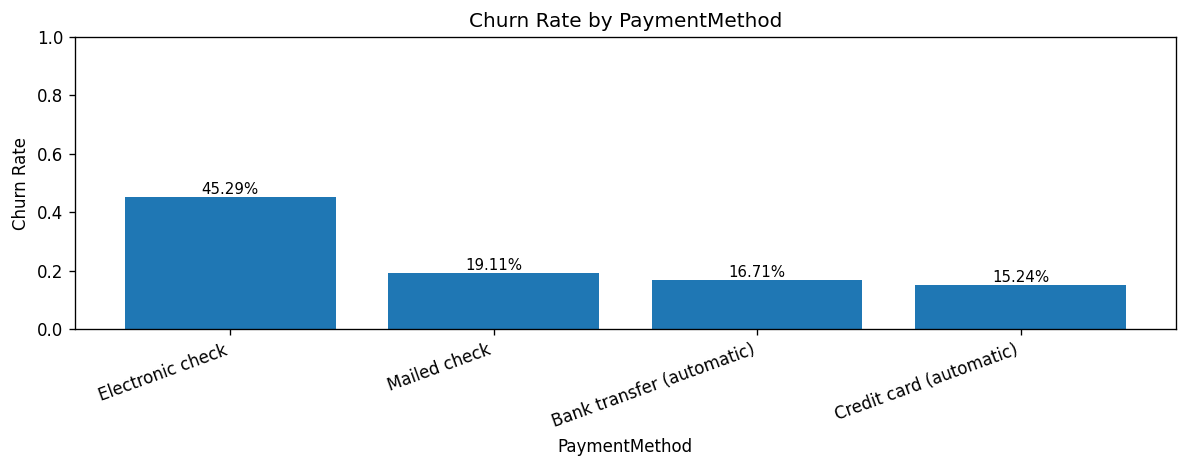

已保存图表: E:\TelecomCustomer_ChurnPrediction\outputs\figures\eda_payment_churn_rate.png


,流失率
PaymentMethod,
Electronic check,0.452854
Mailed check,0.191067
Bank transfer (automatic),0.167098
Credit card (automatic),0.152431


In [6]:
payment_rate = raw_df.groupby('PaymentMethod', dropna=False)['Churn_flag'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 4))
plt.bar(payment_rate.index, payment_rate.values)
plt.title('Churn Rate by PaymentMethod')
plt.xlabel('PaymentMethod')
plt.ylabel('Churn Rate')
plt.ylim(0, 1)
plt.xticks(rotation=20, ha='right')
for x, y in zip(payment_rate.index, payment_rate.values):
    plt.text(x, y, f'{y:.2%}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
out_path = fig_dir / 'eda_payment_churn_rate.png'
plt.savefig(out_path, dpi=150)
plt.show()
print('已保存图表:', out_path)
display(payment_rate.rename('流失率').to_frame())

## 7. InternetService 与 Churn 的交叉流失率分析

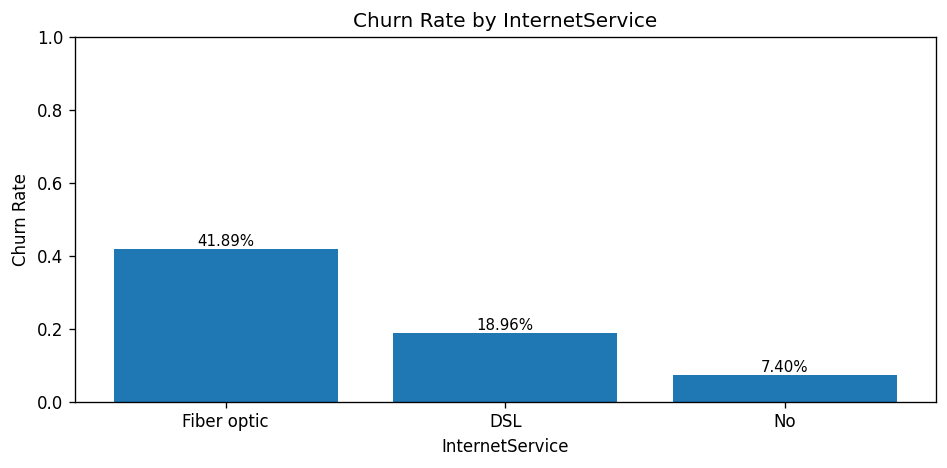

已保存图表: E:\TelecomCustomer_ChurnPrediction\outputs\figures\eda_internet_churn_rate.png


,流失率
InternetService,
Fiber optic,0.418928
DSL,0.189591
No,0.074050


In [7]:
internet_rate = raw_df.groupby('InternetService', dropna=False)['Churn_flag'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
plt.bar(internet_rate.index, internet_rate.values)
plt.title('Churn Rate by InternetService')
plt.xlabel('InternetService')
plt.ylabel('Churn Rate')
plt.ylim(0, 1)
for x, y in zip(internet_rate.index, internet_rate.values):
    plt.text(x, y, f'{y:.2%}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
out_path = fig_dir / 'eda_internet_churn_rate.png'
plt.savefig(out_path, dpi=150)
plt.show()
print('已保存图表:', out_path)
display(internet_rate.rename('流失率').to_frame())

## 8. 数值特征相关性热图

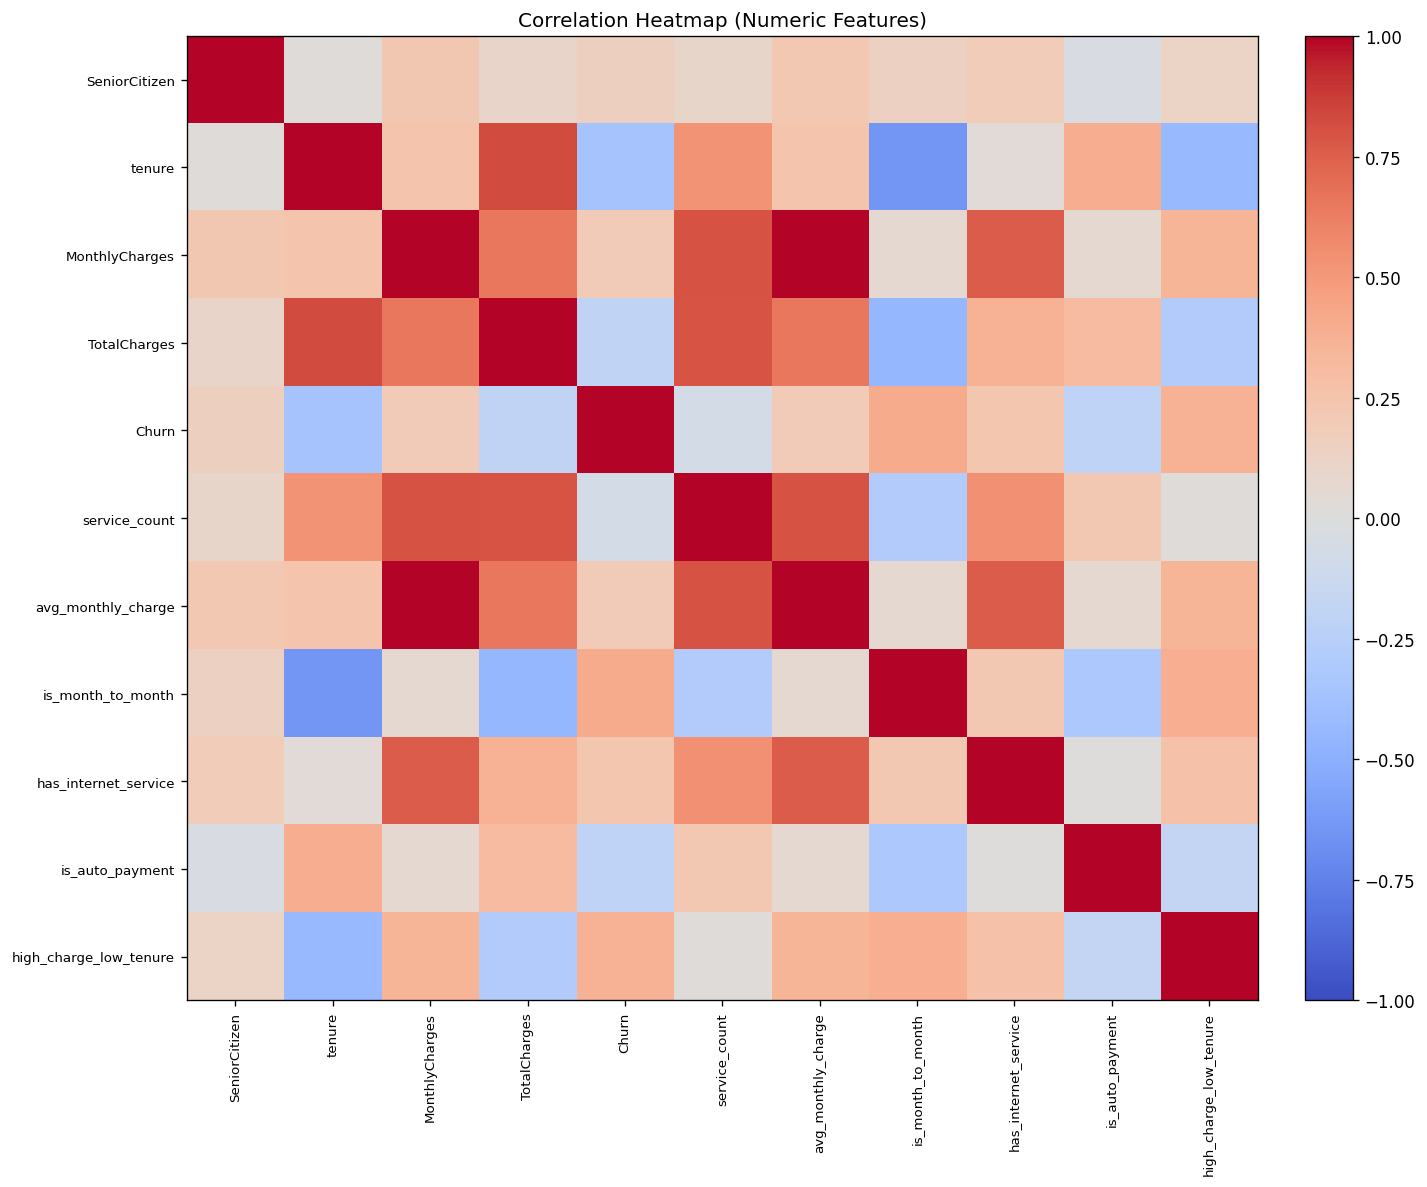

已保存图表: E:\TelecomCustomer_ChurnPrediction\outputs\figures\eda_correlation_heatmap.png


In [8]:
numeric_cols = cleaned_df.select_dtypes(include='number').columns.tolist()
corr = cleaned_df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
im = plt.imshow(corr, interpolation='nearest', aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=8)
plt.yticks(range(len(corr.columns)), corr.columns, fontsize=8)
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
out_path = fig_dir / 'eda_correlation_heatmap.png'
plt.savefig(out_path, dpi=150)
plt.show()
print('已保存图表:', out_path)

## 9. EDA 小结
- 数据存在类别不平衡，未流失样本明显多于流失样本。
- 合同类型和流失风险关系明显，月付客户流失率更高。
- 在网时长（tenure）越短，流失风险越高。
- 月费用与总费用共同反映客户的价格敏感和价值感知。
- 支付方式与互联网服务类型在流失率上也呈现清晰差异。